# Stochastic Gradient Descent by Epoch

One of the fundamental assumptions of Stochastic Gradient Descent (SGD) is that points from the input data (X) are selected independently and randomly. However, this random selection process can be computationally expensive and may also lead to cache misses when working with very large datasets. A solution inspired by Meng et al. (2019) is to shuffle the input data independently at the start, and then iterate through the shuffled data. While shuffling large datasets is itself computationally expensive, this approach significantly improves performance by eliminating the need to randomly select each point during training. However, this procedure deviates from the basic assumption of random sampling, as once a point is selected in an epoch, it cannot be selected again—effectively resulting in sampling without replacement. Nevertheless, we found that this method still achieved convergence in much quicker times.

**Importing Libraries**

In [22]:
from SGD_by_Epoch import shuffle_data, sgd_by_epoch_process
from multiprocessing import Pool
import numpy as np
from sklearn.metrics import mean_squared_error
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt

#### Methodology
The SGD by epoch approach implements the following steps:
1. **Data Pre-processing**: The input feature X and target variable y were normalized to ensure consistent scaling, which improves the stability and efficiency of model training.
2. **Polynomial Basis Function Transformation**: The input feature X was transformed into polynomial features of degree h−1, enabling the model to fit higher-order relationships in the data.
3. **Independent Shuffling of Input Features**: To improve computational efficiency, the data was shuffled independently across t processors at the start of training. Each processor received its own shuffled version of the data, allowing parallel computation without the need for additional shuffling during iterations.
4. **Random Initialization of Weights**: The model weights β were randomly initialized and shared across all processors as the starting point for training.
5. **Processor-specific Epoch Iterations**: Each processor independently iterated through its version of the shuffled data in sequence, for one epoch, updating the weights.
6. **Averaging Results**: After completing each epoch, the t processors returned their estimates of β. These estimates were averaged to obtain a unified global estimate, which was then shared among all processors for the next epoch.
7. **Iterative Updates Across Epochs**: Steps 5 and 6 were repeated for n epochs. The model refined its weights incrementally with each iteration.
8. **Dynamic Learning Rate**: A dynamic learning rate mechanism was introduced to improve stability and convergence during training. The learning rate decreases with the epoch to prevent overshooting during convergence.
Final Weight Extraction: At the conclusion of training, the final β values represented the optimized weights of the model.

**Importing Data**

In [25]:
dataframe = pd.read_excel('dataset1/dataset1.xlsx')

X = dataframe['V'].sort_values()
X = (X-X.mean()) / X.std()
y = dataframe['AT'][X.index].values
y = (y-y.mean()) / y.std()

X = np.reshape(X.values, (-1,1))

**Defining Useful Functions**

In [28]:
def polynomial_basis_function_transformation(X, h):
    """
    Converts an (N * 1) matrix into a (N * h) matrix, where h is the number of basis functions.
    The degree of the polynomial is (h-1).

    Parameters:
    - X: (N * 1) matrix of input features.
    - h: Number of basis functions (degree + 1).

    Returns:
    - X_poly: (N * h) matrix after applying polynomial basis functions.
    """
    powers = np.arange(h)
    X_poly = np.power(X, powers)
    return X_poly

In [31]:
def sgd_by_epoch(X, y, h, alpha, n, t):
    """
    Conducts Linear Regression using SGD with parallelization by epoch.
    """
    start = datetime.now()
    X_poly = polynomial_basis_function_transformation(X, h)
    epoch_size = len(X_poly)
    full_epochs = n // epoch_size

    # Initialize shared weights for the first epoch
    shared_weights = np.random.rand(h)

    # Parallelize shuffling
    with Pool(processes=t) as pool:
        shuffled_data = pool.starmap(shuffle_data, [(X_poly, y) for _ in range(t)])

    mse_history = []  # Track MSE for each epoch

    for epoch in range(full_epochs):
        epoch_start = datetime.now()

        with Pool(processes=t) as pool:
            outputs = pool.starmap(
                sgd_by_epoch_process,
                [(shuffled_data[i][0], shuffled_data[i][1], h, alpha, shared_weights) for i in range(t)]
            )

        shared_weights = np.mean(outputs, axis=0)

        # Calculate MSE for the current epoch
        y_hat_poly = X_poly @ shared_weights
        mse = mean_squared_error(y, y_hat_poly)
        mse_history.append(mse)

        epoch_end = datetime.now()

        print(f"Epoch {epoch + 1}/{full_epochs}, MSE: {mse}, Time for Epoch: {epoch_end - epoch_start}")

    final_beta_hat = shared_weights
    total_end = datetime.now()
    print(f"Total Time for Training: {total_end - start}")

    return mse_history

def plot_mse_vs_epochs(X, y, h, alpha, n):
    t_values = [1, 2, 3, 4, 8]  # List of `t` values
    plt.figure(figsize=(10, 6))

    for t in t_values:
        mse_history = sgd_by_epoch(X, y, h, alpha, n, t)
        plt.plot(range(1, len(mse_history) + 1), mse_history, label=f't={t}')

    plt.xlabel('Epochs')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.title('MSE vs Epochs for Different Number of Processes')
    
    # Set log scale for MSE (y-axis)
    plt.yscale('log')

    # Adding grid and legend
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.xticks(np.arange(1, len(mse_history) + 1, 1))  # Ensure x-axis is integer and includes all epochs
    plt.show()

Epoch 1/20, MSE: 0.27267626029785175, Time for Epoch: 0:00:01.436001
Epoch 2/20, MSE: 0.271930850983768, Time for Epoch: 0:00:01.521352
Epoch 3/20, MSE: 0.27188631903761656, Time for Epoch: 0:00:01.454286
Epoch 4/20, MSE: 0.2718825303397556, Time for Epoch: 0:00:01.504575
Epoch 5/20, MSE: 0.2718821434160703, Time for Epoch: 0:00:01.349089
Epoch 6/20, MSE: 0.2718820958174151, Time for Epoch: 0:00:01.256821
Epoch 7/20, MSE: 0.27188208853891593, Time for Epoch: 0:00:01.275035
Epoch 8/20, MSE: 0.2718820871700074, Time for Epoch: 0:00:01.387183
Epoch 9/20, MSE: 0.2718820868712877, Time for Epoch: 0:00:01.428724
Epoch 10/20, MSE: 0.2718820868003397, Time for Epoch: 0:00:01.481427
Epoch 11/20, MSE: 0.27188208678276826, Time for Epoch: 0:00:01.430229
Epoch 12/20, MSE: 0.2718820867783317, Time for Epoch: 0:00:01.053472
Epoch 13/20, MSE: 0.27188208677720177, Time for Epoch: 0:00:01.469402
Epoch 14/20, MSE: 0.2718820867769129, Time for Epoch: 0:00:01.341360
Epoch 15/20, MSE: 0.27188208677683895, 

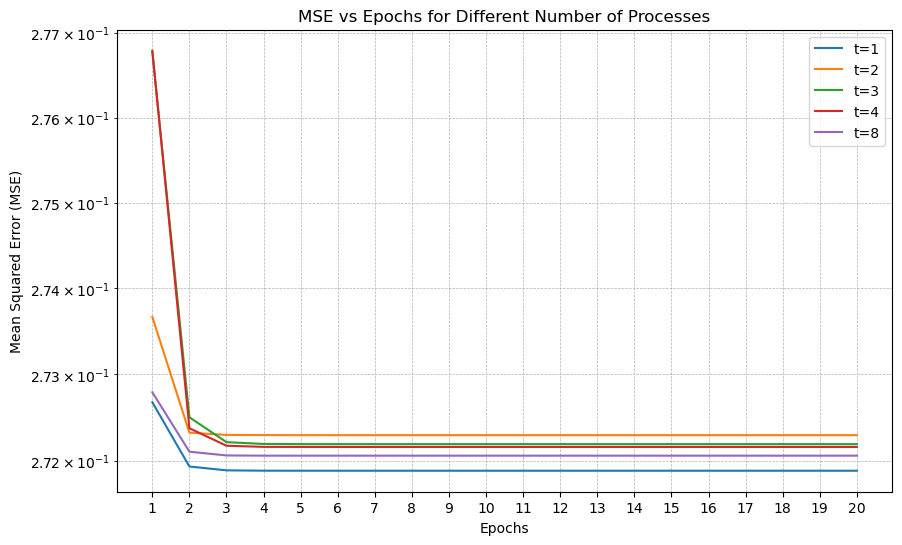

In [35]:
plot_mse_vs_epochs(X, y, 4, 0.001, 200000)

##### Increasing Learning rate

Epoch 1/20, MSE: 0.3780376762146746, Time for Epoch: 0:00:01.227322
Epoch 2/20, MSE: 0.3291593709475626, Time for Epoch: 0:00:01.206187
Epoch 3/20, MSE: 0.3122619700219084, Time for Epoch: 0:00:00.998111
Epoch 4/20, MSE: 0.3007584604667604, Time for Epoch: 0:00:01.085783
Epoch 5/20, MSE: 0.2926653636046804, Time for Epoch: 0:00:01.046915
Epoch 6/20, MSE: 0.2869293035368623, Time for Epoch: 0:00:01.059167
Epoch 7/20, MSE: 0.28283644016320947, Time for Epoch: 0:00:01.014436
Epoch 8/20, MSE: 0.27989699864222173, Time for Epoch: 0:00:01.037235
Epoch 9/20, MSE: 0.2777727757220686, Time for Epoch: 0:00:01.073702
Epoch 10/20, MSE: 0.2762286662911619, Time for Epoch: 0:00:01.029881
Epoch 11/20, MSE: 0.27510010898231524, Time for Epoch: 0:00:01.062190
Epoch 12/20, MSE: 0.2742711201760074, Time for Epoch: 0:00:01.030709
Epoch 13/20, MSE: 0.2736593914367803, Time for Epoch: 0:00:01.064336
Epoch 14/20, MSE: 0.2732061188960065, Time for Epoch: 0:00:01.107267
Epoch 15/20, MSE: 0.2728690182343071, Ti

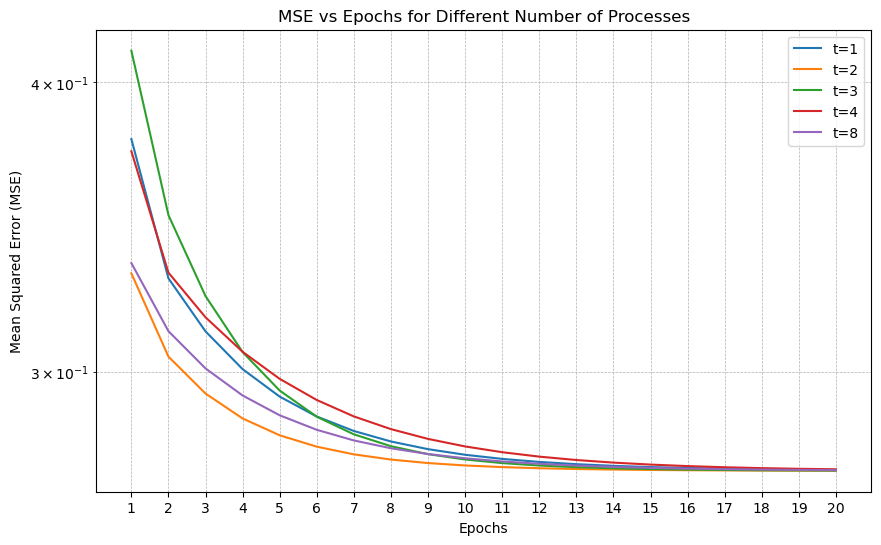

In [37]:
plot_mse_vs_epochs(X, y, 4, 0.0001, 200000)

##### A dynamic learning rate was added to improve convergence during training. Starting with a larger learning rate helped the model learn quickly in the early stages, while gradually reducing it over epochs ensured more stable and precise convergence, preventing overshooting. This adjustment made the model more accurate and consistent as training progressed.

Starting SGD with t=1
Epoch 1/20, MSE: 0.2762148356364793, Time for Epoch: 0:00:01.193203
Epoch 2/20, MSE: 0.2736554372758859, Time for Epoch: 0:00:01.136976
Epoch 3/20, MSE: 0.27322836821187424, Time for Epoch: 0:00:01.070056
Epoch 4/20, MSE: 0.27301033471535985, Time for Epoch: 0:00:01.100616
Epoch 5/20, MSE: 0.2728524963999222, Time for Epoch: 0:00:01.020302
Epoch 6/20, MSE: 0.2727277183152281, Time for Epoch: 0:00:01.385979
Epoch 7/20, MSE: 0.2726259127155193, Time for Epoch: 0:00:01.265947
Epoch 8/20, MSE: 0.27254136150439684, Time for Epoch: 0:00:01.181789
Epoch 9/20, MSE: 0.2724701989020405, Time for Epoch: 0:00:01.432884
Epoch 10/20, MSE: 0.2724096229503106, Time for Epoch: 0:00:01.388573
Epoch 11/20, MSE: 0.2723575364188922, Time for Epoch: 0:00:01.389180
Epoch 12/20, MSE: 0.272312339824663, Time for Epoch: 0:00:01.441539
Epoch 13/20, MSE: 0.27227279662896625, Time for Epoch: 0:00:01.385843
Epoch 14/20, MSE: 0.27223793997686446, Time for Epoch: 0:00:01.044877
Epoch 15/20, MSE:

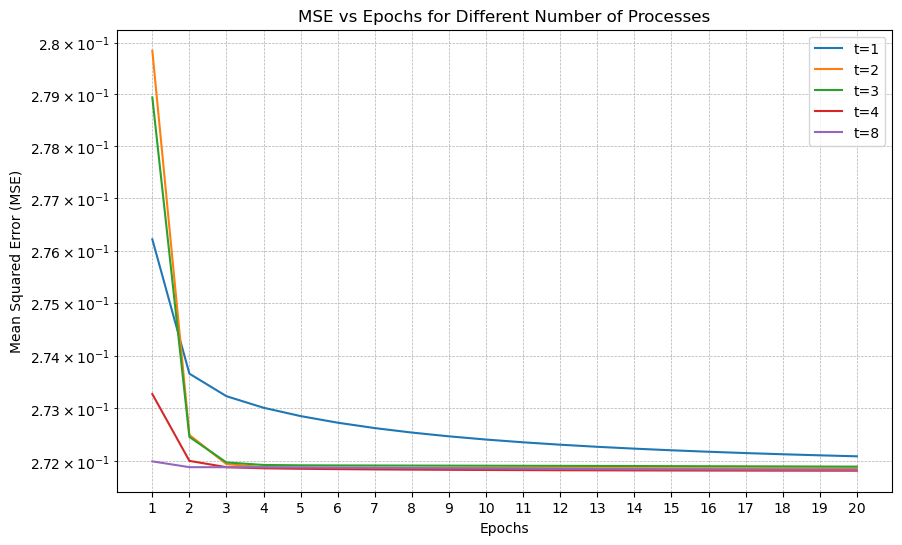

In [41]:
dataframe = pd.read_excel('dataset1.xlsx')

X = dataframe['V'].sort_values()
X = (X - X.mean()) / X.std()
y = dataframe['AT'][X.index].values
y = (y - y.mean()) / y.std()

X = np.reshape(X.values, (-1, 1))

def polynomial_basis_function_transformation(X, h):
    """
    Converts an (N * 1) matrix into a (N * h) matrix, where h is the number of basis functions.
    The degree of the polynomial is (h-1).

    Parameters:
    - X: (N * 1) matrix of input features.
    - h: Number of basis functions (degree + 1).

    Returns:
    - X_poly: (N * h) matrix after applying polynomial basis functions.
    """
    powers = np.arange(h)
    X_poly = np.power(X, powers)
    return X_poly


def sgd_by_epoch(X, y, h, b_alpha, n, t):
    """
    Conducts Linear Regression using SGD with parallelization by epoch.
    """
    start = datetime.now()
    X_poly = polynomial_basis_function_transformation(X, h)
    epoch_size = len(X_poly)
    full_epochs = n // epoch_size

    shared_weights = np.random.rand(h)

    with Pool(processes=t) as pool:
        shuffled_data = pool.starmap(shuffle_data, [(X_poly, y) for _ in range(t)])

    mse_history = []  # Track MSE for each epoch
    
    """
    To improve the stability and convergence of the training process, 
    implemented a dynamic learning rate mechanism. 
    This adjustment allowed the learning rate to adapt progressively during training, 
    ensuring continuous convergence of the epochs.
    """
    for epoch in range(full_epochs):
        alpha = dynamic_learning_rate(epoch, b_alpha)
        epoch_start = datetime.now()

        with Pool(processes=t) as pool:
            outputs = pool.starmap(
                sgd_by_epoch_process,
                [(shuffled_data[i][0], shuffled_data[i][1], h, alpha, shared_weights) for i in range(t)]
            )

        shared_weights = np.mean(outputs, axis=0)

        y_hat_poly = X_poly @ shared_weights
        mse = mean_squared_error(y, y_hat_poly)
        mse_history.append(mse)

        epoch_end = datetime.now()

        print(f"Epoch {epoch + 1}/{full_epochs}, MSE: {mse}, Time for Epoch: {epoch_end - epoch_start}")

    final_beta_hat = shared_weights
    total_end = datetime.now()
    print(f"Total Time for Training: {total_end - start}")

    return mse_history

# Adding function for dynamic learning rate
def dynamic_learning_rate(epoch, base_alpha, decay_rate=0.1):
    return base_alpha / (1 + decay_rate * epoch)

# Plotting Function with Debugging
def plot_mse_vs_epochs(X, y, h, alpha, n):
    t_values = [1, 2, 3, 4, 8]  # List of `t` values
    plt.figure(figsize=(10, 6))

    for t in t_values:
        print(f"Starting SGD with t={t}")
        mse_history = sgd_by_epoch(X, y, h, alpha, n, t)
        print(f"MSE history for t={t}: {mse_history}")  # Debug statement
        if mse_history:  # Ensure there's data to plot
            plt.plot(range(1, len(mse_history) + 1), mse_history, label=f't={t}')
        else:
            print(f"No data to plot for t={t}")

    plt.xlabel('Epochs')
    plt.ylabel('Mean Squared Error (MSE)')
    plt.title('MSE vs Epochs for Different Number of Processes')

    # Set log scale for MSE (y-axis)
    plt.yscale('log')

    # Adding grid and legend
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.xticks(np.arange(1, len(mse_history) + 1, 1))  # Ensure x-axis is integer and includes all epochs
    plt.show()


plot_mse_vs_epochs(X, y, 4, 0.001, 200000)

##### Increasing Learning rate after dynamic learning 

Starting SGD with t=1
Epoch 1/20, MSE: 0.3191986736975012, Time for Epoch: 0:00:00.977134
Epoch 2/20, MSE: 0.2816146638530808, Time for Epoch: 0:00:01.036367
Epoch 3/20, MSE: 0.2781824191999122, Time for Epoch: 0:00:01.016948
Epoch 4/20, MSE: 0.2763763572838936, Time for Epoch: 0:00:01.066895
Epoch 5/20, MSE: 0.2751631144565645, Time for Epoch: 0:00:01.035282
Epoch 6/20, MSE: 0.2743227746637377, Time for Epoch: 0:00:01.064265
Epoch 7/20, MSE: 0.27372782369294935, Time for Epoch: 0:00:01.276062
Epoch 8/20, MSE: 0.2732979260741455, Time for Epoch: 0:00:01.633109
Epoch 9/20, MSE: 0.2729814799891013, Time for Epoch: 0:00:01.034049
Epoch 10/20, MSE: 0.2727446253144491, Time for Epoch: 0:00:01.420526
Epoch 11/20, MSE: 0.2725646592491564, Time for Epoch: 0:00:01.338834
Epoch 12/20, MSE: 0.27242604845987817, Time for Epoch: 0:00:01.428465
Epoch 13/20, MSE: 0.2723179657853109, Time for Epoch: 0:00:01.385482
Epoch 14/20, MSE: 0.2722327354849922, Time for Epoch: 0:00:01.378587
Epoch 15/20, MSE: 0

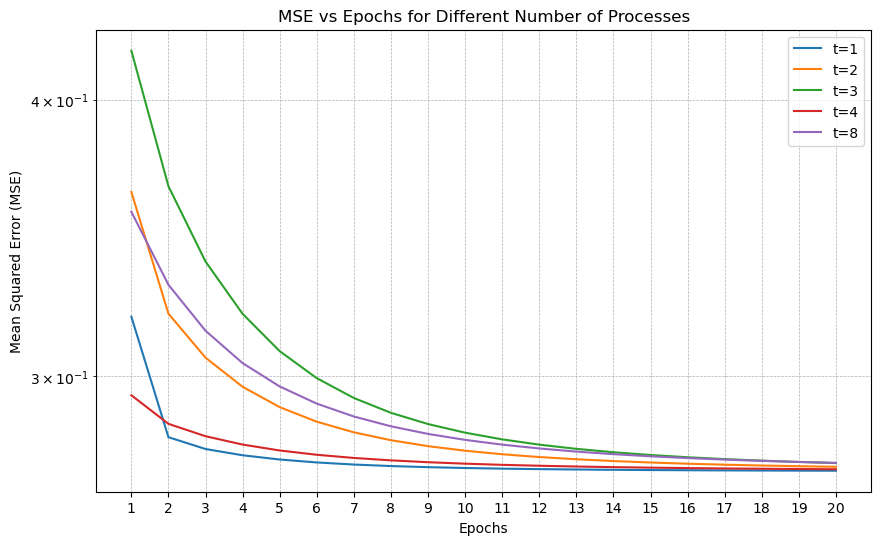

In [43]:
plot_mse_vs_epochs(X, y, 4, 0.0001, 200000)

##### By increasing the number of iterations (n), the effect on MSE and computation time was analyzed. For fewer iterations, the MSE values across threads showed wider gaps, indicating less consistent convergence. However, with more iterations, convergence became more uniform, though computations were heavier. After balancing these factors, 200,000 to 300,000 iterations were identified as optimal, offering a good trade-off between computational efficiency and a well-converged MSE graph.

Starting SGD with t=1
Epoch 1/31, MSE: 0.3994833559321033, Time for Epoch: 0:00:00.994537
Epoch 2/31, MSE: 0.33793754444240653, Time for Epoch: 0:00:01.017604
Epoch 3/31, MSE: 0.3187435104175713, Time for Epoch: 0:00:01.047584
Epoch 4/31, MSE: 0.3065605035839472, Time for Epoch: 0:00:01.053570
Epoch 5/31, MSE: 0.2982037748585947, Time for Epoch: 0:00:01.045577
Epoch 6/31, MSE: 0.2922874989159551, Time for Epoch: 0:00:01.122269
Epoch 7/31, MSE: 0.28799299036680465, Time for Epoch: 0:00:01.026419
Epoch 8/31, MSE: 0.28480760110990183, Time for Epoch: 0:00:01.065328
Epoch 9/31, MSE: 0.28239948637746815, Time for Epoch: 0:00:01.058244
Epoch 10/31, MSE: 0.2805479240410964, Time for Epoch: 0:00:01.019797
Epoch 11/31, MSE: 0.2791025762128467, Time for Epoch: 0:00:01.031996
Epoch 12/31, MSE: 0.2779588560764384, Time for Epoch: 0:00:01.037821
Epoch 13/31, MSE: 0.27704260791832014, Time for Epoch: 0:00:01.049202
Epoch 14/31, MSE: 0.27630034017697563, Time for Epoch: 0:00:01.067577
Epoch 15/31, MS

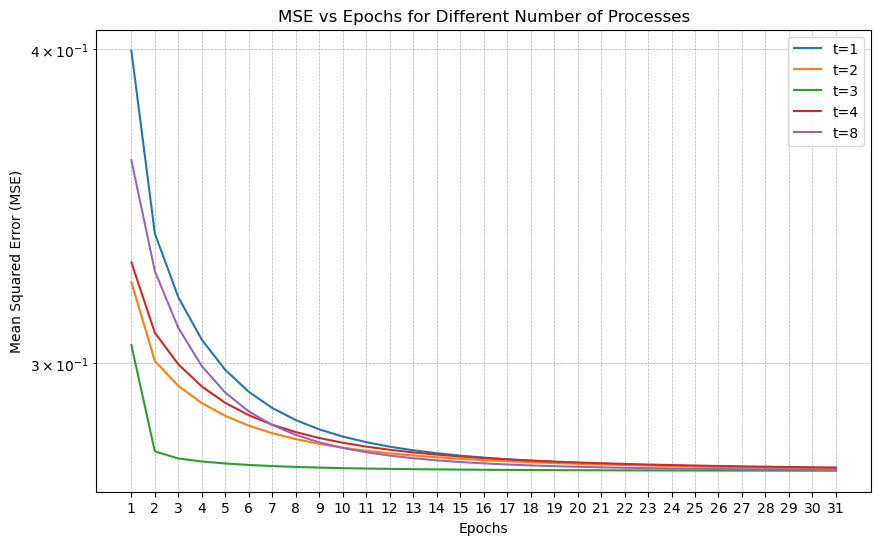

In [45]:
plot_mse_vs_epochs(X, y, 4, 0.0001, 300000)